In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as py
pd.set_option('display.float_format', lambda x: '%.6f' % x)

In [2]:
df1 = pd.read_csv('cost-per-transaction-percent.csv')
df2 = pd.read_csv('difficulty.csv')
df3 = pd.read_csv('hash-rate.csv')
df4 = pd.read_csv('market-price.csv')
df5 = pd.read_csv('miners-revenue.csv')
df6 = pd.read_csv('n-transactions-total.csv')
df7 = pd.read_csv('transaction-fees.csv')
df8 = pd.read_csv('output-volume.csv')

In [3]:
df1.head()

,Timestamp,Cost_per_transaction_percent
0,1/23/2025 0:00,0.308462
1,1/24/2025 0:00,0.385129
2,1/25/2025 0:00,1.167048
3,1/26/2025 0:00,1.652051
4,1/27/2025 0:00,0.415520


In [4]:
df2.head()

,Timestamp,Difficulty
0,1/23/2025 0:00,110451907374650
1,1/24/2025 0:00,110451907374650
2,1/25/2025 0:00,110451907374650
3,1/26/2025 0:00,110451907374650
4,1/27/2025 0:00,108526595760699


In [5]:
df3.head()

,Timestamp,Hash-rate
0,1/23/2025 0:00,746720797.200000
1,1/24/2025 0:00,768683173.500000
2,1/25/2025 0:00,702796044.400000
3,1/26/2025 0:00,752211391.200000
4,1/27/2025 0:00,841602268.600000


In [6]:
df4.head()

,Timestamp,Market_price
0,1/23/2025 0:00,103637.060000
1,1/24/2025 0:00,103950.370000
2,1/25/2025 0:00,104855.000000
3,1/26/2025 0:00,104722.360000
4,1/27/2025 0:00,102592.630000


In [7]:
df5.head()

,Timestamp,Miners_revenue
0,1/23/2025 0:00,45141421.670000
1,1/24/2025 0:00,46593684.650000
2,1/25/2025 0:00,43120149.290000
3,1/26/2025 0:00,45984551.190000
4,1/27/2025 0:00,49678699.310000


In [8]:
df6.head()

,Timestamp,N_transactions_total
0,1/23/2025 0:00,1146693089
1,1/24/2025 0:00,1147018975
2,1/25/2025 0:00,1147388306
3,1/26/2025 0:00,1147724391
4,1/27/2025 0:00,1148034901


In [9]:
df7.head()

,Timestamp,Transaction_fees
0,1/23/2025 0:00,6.800648
1,1/24/2025 0:00,6.466193
2,1/25/2025 0:00,5.433939
3,1/26/2025 0:00,4.197875
4,1/27/2025 0:00,6.136747


In [10]:
df8.head()

,Timestamp,Output_volume
0,1/23/2025 0:00,853792.998100
1,1/24/2025 0:00,704594.104400
2,1/25/2025 0:00,436039.010000
3,1/26/2025 0:00,403647.248700
4,1/27/2025 0:00,688610.645100


---

# Data Preprocessing

In [11]:
# First, let's investigate the timestamp ranges in each dataframe
for i, df in enumerate([df1, df2, df3, df4, df5, df6, df7, df8], 1):
    if 'Timestamp' in df.columns:
        print(f"df{i} timestamp range: {df['Timestamp'].min()} to {df['Timestamp'].max()}")
        print(f"df{i} timestamp dtype: {df['Timestamp'].dtype}")
        print(f"Sample first few timestamps in df{i}:")
        print(df['Timestamp'].head())
        print("-" * 50)

# Now let's fix the issue by ensuring all timestamps are in the correct format
# First, make sure all Timestamp columns are datetime objects
for i, df in enumerate([df1, df2, df3, df4, df5, df6, df7, df8], 1):
    if 'Timestamp' in df.columns:
        # Check if it's already a datetime
        if not pd.api.types.is_datetime64_any_dtype(df['Timestamp']):
            # Convert to datetime - adjust format as needed
            df['Timestamp'] = pd.to_datetime(df['Timestamp'])
        
        # If you want to filter to only include dates from 1/23/2026 onwards
        # df = df[df['Timestamp'] >= pd.to_datetime('2026-01-23')]
        
        # Update the original dataframe reference
        globals()[f'df{i}'] = df

# Now merge the dataframes with the corrected timestamps
combined_df = df1.copy()
dataframes = [df2, df3, df4, df5, df6, df7, df8]
for df in dataframes:
    combined_df = combined_df.merge(df, on='Timestamp', how='outer')

# Sort by timestamp to see the progression clearly
combined_df = combined_df.sort_values('Timestamp')

# Display the first few rows to check the earliest timestamps
print("First few rows of the combined dataframe:")
combined_df.head()

df1 timestamp range: 1/1/2026 0:00 to 9/9/2025 0:00
df1 timestamp dtype: object
Sample first few timestamps in df1:
0    1/23/2025 0:00
1    1/24/2025 0:00
2    1/25/2025 0:00
3    1/26/2025 0:00
4    1/27/2025 0:00
Name: Timestamp, dtype: object
--------------------------------------------------
df2 timestamp range: 1/1/2026 0:00 to 9/9/2025 0:00
df2 timestamp dtype: object
Sample first few timestamps in df2:
0    1/23/2025 0:00
1    1/24/2025 0:00
2    1/25/2025 0:00
3    1/26/2025 0:00
4    1/27/2025 0:00
Name: Timestamp, dtype: object
--------------------------------------------------
df3 timestamp range: 1/1/2026 0:00 to 9/9/2025 0:00
df3 timestamp dtype: object
Sample first few timestamps in df3:
0    1/23/2025 0:00
1    1/24/2025 0:00
2    1/25/2025 0:00
3    1/26/2025 0:00
4    1/27/2025 0:00
Name: Timestamp, dtype: object
--------------------------------------------------
df4 timestamp range: 1/1/2026 0:00 to 9/9/2025 0:00
df4 timestamp dtype: object
Sample first few timestamp

,Timestamp,Cost_per_transaction_percent,Difficulty,Hash-rate,Market_price,Miners_revenue,N_transactions_total,Transaction_fees,Output_volume
0,2025-01-23,0.308462,110451907374650.000000,746720797.200000,103637.060000,45141421.670000,1146693089.000000,6.800648,853792.998100
1,2025-01-24,0.385129,110451907374650.000000,768683173.500000,103950.370000,46593684.650000,1147018975.000000,6.466193,704594.104400
2,2025-01-25,1.167048,110451907374650.000000,702796044.400000,104855.000000,43120149.290000,1147388306.000000,5.433939,436039.010000
3,2025-01-26,1.652051,110451907374650.000000,752211391.200000,104722.360000,45984551.190000,1147724391.000000,4.197875,403647.248700
4,2025-01-27,0.415520,108526595760699.000000,841602268.600000,102592.630000,49678699.310000,1148034901.000000,6.136747,688610.645100


In [12]:
df = combined_df
df.head()

,Timestamp,Cost_per_transaction_percent,Difficulty,Hash-rate,Market_price,Miners_revenue,N_transactions_total,Transaction_fees,Output_volume
0,2025-01-23,0.308462,110451907374650.000000,746720797.200000,103637.060000,45141421.670000,1146693089.000000,6.800648,853792.998100
1,2025-01-24,0.385129,110451907374650.000000,768683173.500000,103950.370000,46593684.650000,1147018975.000000,6.466193,704594.104400
2,2025-01-25,1.167048,110451907374650.000000,702796044.400000,104855.000000,43120149.290000,1147388306.000000,5.433939,436039.010000
3,2025-01-26,1.652051,110451907374650.000000,752211391.200000,104722.360000,45984551.190000,1147724391.000000,4.197875,403647.248700
4,2025-01-27,0.415520,108526595760699.000000,841602268.600000,102592.630000,49678699.310000,1148034901.000000,6.136747,688610.645100


In [13]:
# Check Dataset Length
df.shape

(366, 9)

In [14]:
# Statistical Information
df.describe()

,Timestamp,Cost_per_transaction_percent,Difficulty,Hash-rate,Market_price,Miners_revenue,N_transactions_total,Transaction_fees,Output_volume
count,366,364.000000,362.000000,362.000000,366.000000,365.000000,362.000000,362.000000,363.000000
mean,2025-07-24 12:00:00.000000256,0.666745,130680215435056.125000,942549791.355801,101251.663497,47473326.410630,1220419031.895028,4.453376,673133.612041
min,2025-01-23 00:00:00,0.066088,108105433845147.000000,671743783.100000,76266.570000,32874235.570000,1146693089.000000,1.864242,275838.598500
25%,2025-04-24 06:00:00,0.360007,119116256505723.000000,853905956.675000,90501.147500,40939035.120000,1182391010.250000,3.017770,542577.586700
50%,2025-07-24 12:00:00,0.476061,126982285146988.000000,929996674.300000,103262.970000,47226883.770000,1216751276.500000,4.195552,665074.405900
75%,2025-10-23 18:00:00,0.805813,146716052770107.000000,1035426238.750000,110962.290000,53304513.960000,1259283258.750000,5.304727,775722.755250
max,2026-01-23 00:00:00,2.338466,155973032196072.000000,1305499723.000000,124776.680000,67896489.580000,1300176792.000000,13.873252,1495590.690000
std,NaN,0.460429,14668121446890.820312,127449118.823854,11920.085992,7387614.907636,45005699.824169,1.911699,193431.589700


In [15]:
# Data Type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Timestamp                     366 non-null    datetime64[ns]
 1   Cost_per_transaction_percent  364 non-null    float64       
 2   Difficulty                    362 non-null    float64       
 3   Hash-rate                     362 non-null    float64       
 4   Market_price                  366 non-null    float64       
 5   Miners_revenue                365 non-null    float64       
 6   N_transactions_total          362 non-null    float64       
 7   Transaction_fees              362 non-null    float64       
 8   Output_volume                 363 non-null    float64       
dtypes: datetime64[ns](1), float64(8)
memory usage: 25.9 KB


In [16]:
#Check Missing Values
df.isnull().sum()

Timestamp                       0
Cost_per_transaction_percent    2
Difficulty                      4
Hash-rate                       4
Market_price                    0
Miners_revenue                  1
N_transactions_total            4
Transaction_fees                4
Output_volume                   3
dtype: int64

In [18]:
mv = df.isnull()
mv

,Timestamp,Cost_per_transaction_percent,Difficulty,Hash-rate,Market_price,Miners_revenue,N_transactions_total,Transaction_fees,Output_volume
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
361,False,False,False,False,False,False,False,False,False
362,False,False,False,False,False,False,False,False,False
363,False,False,False,False,False,False,False,False,False
364,False,False,False,False,False,False,False,False,False


In [19]:
columns = list(df.columns)
columns

['Timestamp',
 'Cost_per_transaction_percent',
 'Difficulty',
 'Hash-rate',
 'Market_price',
 'Miners_revenue',
 'N_transactions_total',
 'Transaction_fees',
 'Output_volume']

In [20]:
columns.remove("Timestamp")
columns

['Cost_per_transaction_percent',
 'Difficulty',
 'Hash-rate',
 'Market_price',
 'Miners_revenue',
 'N_transactions_total',
 'Transaction_fees',
 'Output_volume']

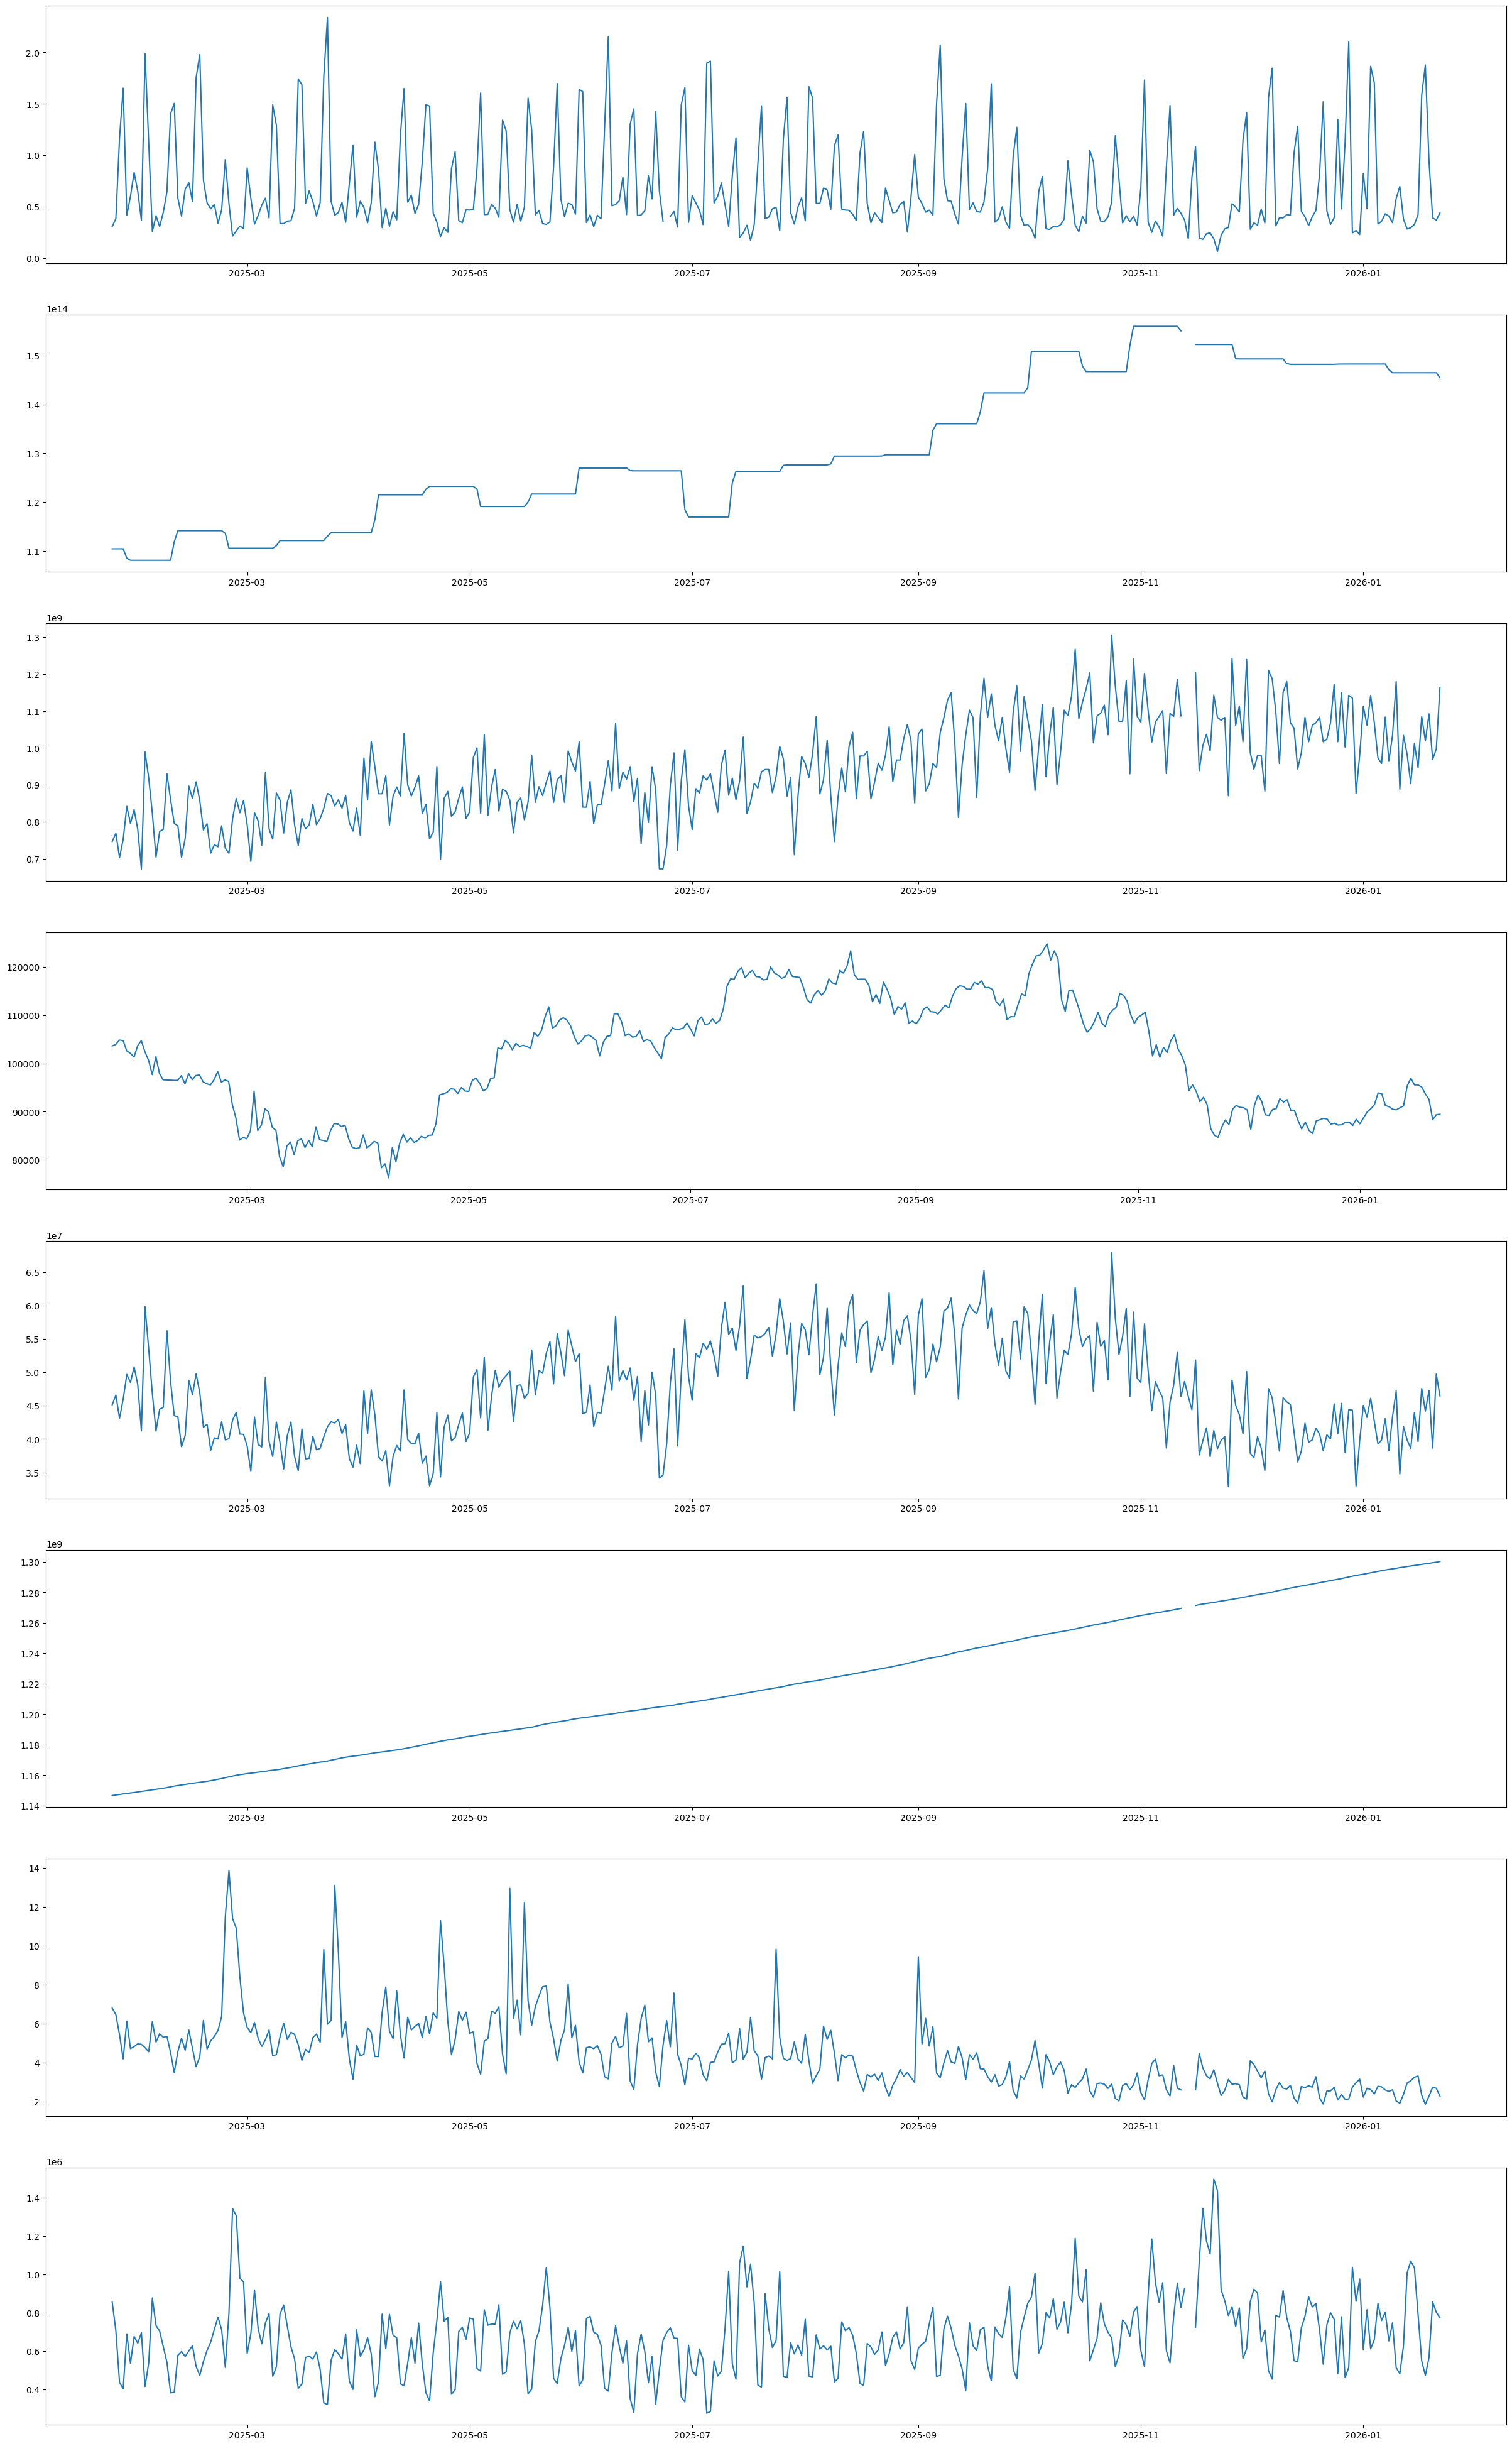

In [28]:
fig = py.figure(figsize = (30, 50))

COLUMNS = 1
ROWS = 8

for index in range(len(columns)):
    fig.add_subplot(ROWS, COLUMNS, index + 1)
    current_feature = columns[index]
    py.plot(df["Timestamp"], df[current_feature])

py.show()
    